In [ ]:
# WEEKLY SALES ANALYSIS ON WALMART SALES DATA
# Ece Gazioğlu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub
import seaborn as sns

In [2]:
path = kagglehub.dataset_download("mikhail1681/walmart-sales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'walmart-sales' dataset.
Path to dataset files: /kaggle/input/walmart-sales


In [3]:
os.listdir(path)

['Walmart_Sales.csv']

In [4]:
walmart=pd.read_csv(os.path.join(path,'Walmart_Sales.csv'))
walmart.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
# supervised, regression
# about the task
# we have weekly sales as target, i can train a model to predict weekly sales
# also i can determine what feature affects most the weekly sales (#components)
# so i can use/compare these models; for baseline; OLS, for comparison; Lasso,Ridge,ElasticNet,SVR, randomforestregressor and xgboost
# and find out is this model selection shift meaningful via Friedman test


In [6]:
# EDA

In [7]:
walmart.shape

(6435, 8)

In [8]:
walmart.info()
# no nulls
# date is in object type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [9]:
walmart[walmart.duplicated(keep=False)]
# no dups

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment


In [10]:
walmart.describe().T
# since we dont have any metadata about this data, i need to examine thoroughly

,count,mean,std,min,25%,50%,75%,max
Store,6435.0,2.300000e+01,12.988182,1.000,12.000,23.000000,3.400000e+01,4.500000e+01
Weekly_Sales,6435.0,1.046965e+06,564366.622054,209986.250,553350.105,960746.040000,1.420159e+06,3.818686e+06
Holiday_Flag,6435.0,6.993007e-02,0.255049,0.000,0.000,0.000000,0.000000e+00,1.000000e+00
Temperature,6435.0,6.066378e+01,18.444933,-2.060,47.460,62.670000,7.494000e+01,1.001400e+02
Fuel_Price,6435.0,3.358607e+00,0.459020,2.472,2.933,3.445000,3.735000e+00,4.468000e+00
CPI,6435.0,1.715784e+02,39.356712,126.064,131.735,182.616521,2.127433e+02,2.272328e+02
Unemployment,6435.0,7.999151e+00,1.875885,3.879,6.891,7.874000,8.622000e+00,1.431300e+01


<Axes: ylabel='Frequency'>

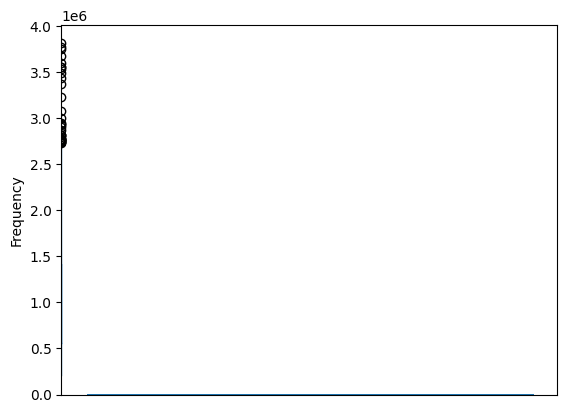

In [11]:
walmart["Weekly_Sales"].plot(kind="hist")
walmart["Weekly_Sales"].plot(kind="box")

In [12]:
walmart["Weekly_Sales"].describe().T

,Weekly_Sales
count,6.435000e+03
mean,1.046965e+06
std,5.643666e+05
min,2.099862e+05
25%,5.533501e+05
50%,9.607460e+05
75%,1.420159e+06
max,3.818686e+06


In [13]:
print(walmart["Store"].nunique())
print(walmart["Date"].nunique())
walmart[walmart.duplicated(subset=["Store","Date"])]

45
143


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment


In [14]:
walmart["Store"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [15]:
summary = pd.DataFrame({
    "count": [walmart["Date"].nunique()],
    "min": [walmart["Date"].min()],
    "max": [walmart["Date"].max()]
})

print(summary)
# i need to transform this column into datetime first

   count         min         max
0    143  01-04-2011  31-12-2010


In [16]:
# of course,lets check first
walmart[walmart["Date"].str.len()!=10]["Date"]
walmart[~walmart["Date"].str.contains("-")]
walmart[~walmart["Date"].str.match(r"^\d{2}-\d{2}-\d{4}$")]
walmart["Date"].sample(10)  # dd-mm-YYYY

,Date
4170,16-07-2010
3686,23-03-2012
5606,27-08-2010
2747,03-09-2010
4249,20-01-2012
1827,23-03-2012
2809,11-11-2011
4187,12-11-2010
40,12-11-2010
724,09-04-2010


In [17]:
walmart_copy=walmart.copy()

In [18]:
pd.to_datetime?

In [19]:
walmart_copy["Date"]=pd.to_datetime(walmart_copy["Date"],format="%d-%m-%Y")

In [20]:
walmart_copy.info()
display(walmart["Date"].head())
display(walmart_copy["Date"].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


,Date
0,05-02-2010
1,12-02-2010
2,19-02-2010
3,26-02-2010
4,05-03-2010


,Date
0,2010-02-05
1,2010-02-12
2,2010-02-19
3,2010-02-26
4,2010-03-05


In [21]:
walmart_copy["Holiday_Flag"].unique()
walmart_copy["Holiday_Flag"].value_counts()  # expected imbalance

,count
Holiday_Flag,
0,5985
1,450


In [22]:
np.corrcoef(walmart_copy["Holiday_Flag"],walmart_copy["Weekly_Sales"])

array([[1.        , 0.03689097],
       [0.03689097, 1.        ]])

In [23]:
walmart_copy[walmart_copy["Holiday_Flag"]==1]

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
31,1,2010-09-10,1507460.69,1,78.69,2.565,211.495190,7.787
42,1,2010-11-26,1955624.11,1,64.52,2.735,211.748433,7.838
47,1,2010-12-31,1367320.01,1,48.43,2.943,211.404932,7.838
53,1,2011-02-11,1649614.93,1,36.39,3.022,212.936705,7.742
...,...,...,...,...,...,...,...,...
6375,45,2011-09-09,746129.56,1,71.48,3.738,186.673738,8.625
6386,45,2011-11-25,1170672.94,1,48.71,3.492,188.350400,8.523
6391,45,2011-12-30,869403.63,1,37.79,3.389,189.062016,8.523
6397,45,2012-02-10,803657.12,1,37.00,3.640,189.707605,8.424


In [24]:
walmart_copy["Weekly_Sales"].mean()

np.float64(1046964.8775617715)

In [25]:
walmart_copy[(walmart_copy["Weekly_Sales"]<1046964)]["Holiday_Flag"].value_counts()

,count
Holiday_Flag,
0,3328
1,231


In [26]:
walmart_copy[walmart_copy["Weekly_Sales"]<walmart_copy.groupby("Store")["Weekly_Sales"].transform("mean")]

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106
...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667


In [27]:
holiday=walmart_copy.groupby(["Store","Holiday_Flag"]).mean()["Weekly_Sales"].unstack()

In [28]:
holiday[1]-holiday[0]
# stores 30,36,37,38,44 shows different behavior than others,,their sales higher in the nonholiday weeks
# i need further information in order to give an insight about this but maybe i can say that those stores located in business areas that are crowded on business days

,0
Store,
1,118790.270361
2,165058.088120
3,37746.203609
4,159546.780842
5,44609.330083
6,124915.059556
7,109435.810188
8,71587.457519
9,48351.491827


<Axes: ylabel='Frequency'>

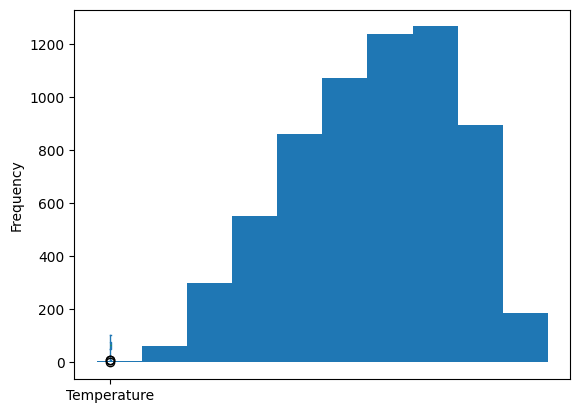

In [29]:
walmart_copy["Temperature"].plot(kind="hist")
walmart_copy["Temperature"].plot(kind="box")

In [30]:
walmart_copy["Temperature"].describe().T
# its in fahrenheit, between -19 C and 38 C,,reasonable

,Temperature
count,6435.000000
mean,60.663782
std,18.444933
min,-2.060000
25%,47.460000
50%,62.670000
75%,74.940000
max,100.140000


2.472

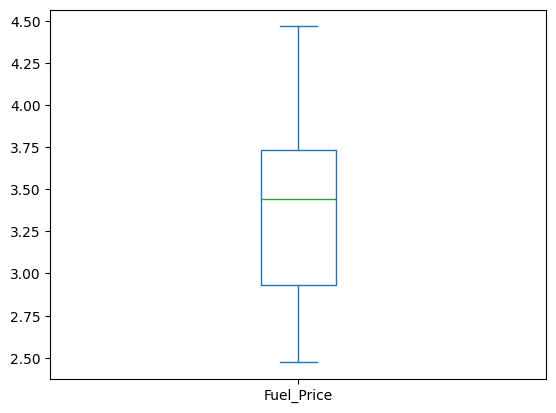

In [31]:
walmart_copy["Fuel_Price"].plot(kind="box")
walmart_copy["Fuel_Price"].min()

In [32]:
walmart_copy["Fuel_Price"].head()

,Fuel_Price
0,2.572
1,2.548
2,2.514
3,2.561
4,2.625


In [33]:
walmart_copy["CPI"].head()
# # CPI is originally reported monthly but converted to weekly observations in this dataset.

,CPI
0,211.096358
1,211.242170
2,211.289143
3,211.319643
4,211.350143


<Axes: >

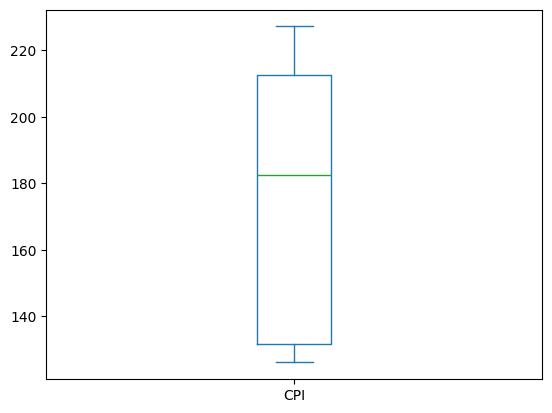

In [34]:
walmart_copy["CPI"].plot(kind="box")
# no outliers

In [35]:
walmart_copy[["Date","Unemployment"]].head(10)

,Date,Unemployment
0,2010-02-05,8.106
1,2010-02-12,8.106
2,2010-02-19,8.106
3,2010-02-26,8.106
4,2010-03-05,8.106
5,2010-03-12,8.106
6,2010-03-19,8.106
7,2010-03-26,8.106
8,2010-04-02,7.808
9,2010-04-09,7.808


<Axes: >

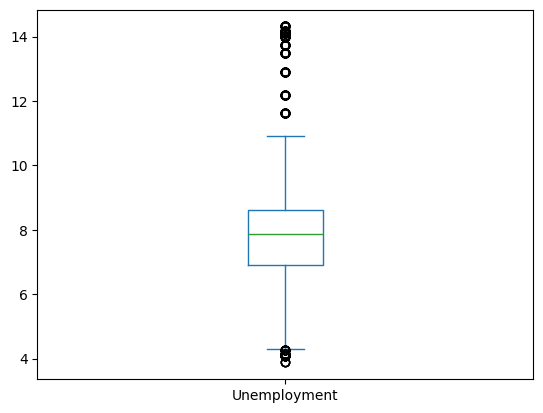

In [36]:
walmart_copy["Unemployment"].plot(kind="box")

In [37]:
walmart_copy["Unemployment"].describe().T

,Unemployment
count,6435.000000
mean,7.999151
std,1.875885
min,3.879000
25%,6.891000
50%,7.874000
75%,8.622000
max,14.313000


<Axes: ylabel='Frequency'>

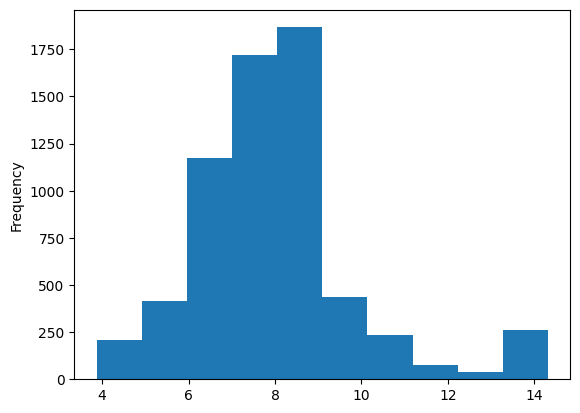

In [38]:
walmart_copy["Unemployment"].plot(kind="hist")

In [39]:
# store--45 store
# date--was in object type, every monday is entered,  type changed into datetime,
# weekly_sales--sales of each week,,amount or revenue? according to data owner its revenue in k
# holiday_flag--binary
# temperature--in fahrenheit,a few outliers but possible, wont treated as outlier
# fuel_price--no outliers,weekly
# cpi--no outliers,originally monthly converted to weekly
# unemployment--originally quarterly, not converted in to weekly, possible edge values

<Axes: >

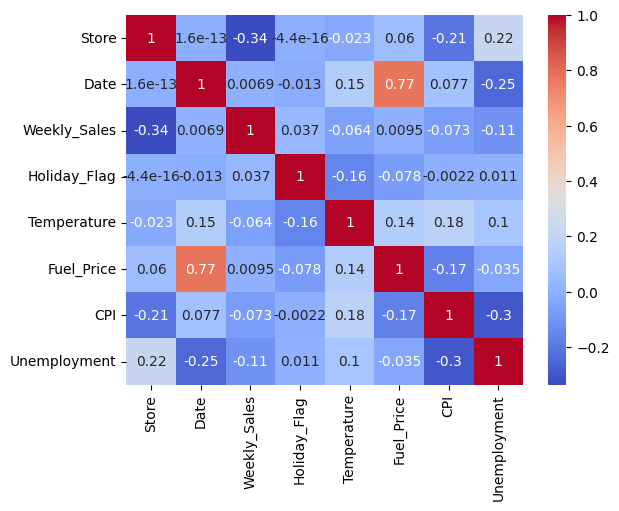

In [40]:
# correlation between features
sns.heatmap(walmart_copy.corr(),annot=True,cmap="coolwarm")

In [41]:
correlations = walmart_copy.select_dtypes("number").corr()["Weekly_Sales"].sort_values()

In [42]:
correlations
# we expect that holidays have the biggest impact but as i can see general economy affect our sales
# from this, i can say that maybe our brand is a luxury goods brand.

,Weekly_Sales
Store,-0.335332
Unemployment,-0.106176
CPI,-0.072634
Temperature,-0.063810
Fuel_Price,0.009464
Holiday_Flag,0.036891
Weekly_Sales,1.000000


In [43]:
# a little time series plotting for unemployment, fuel price, cpi
# i know that temperature shows us seasonality but no harm to look
# i want to seperate into 2 those stores; just instincts, normal behavior stores which have higher sales in holidays and abnormal stores(30,36,37,38,44)
abnormal_stores=[30,36,37,38,44]

Text(0.5, 1.0, 'normal stores, sample store 2')

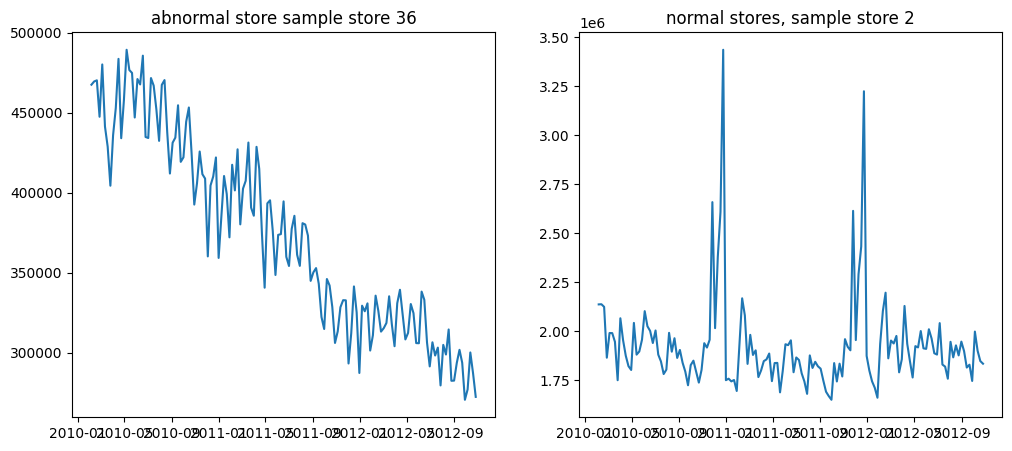

In [44]:
store_abnrm = walmart_copy[walmart_copy["Store"]==36]
store_nrm= walmart_copy[walmart_copy["Store"]==2]
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].plot(store_abnrm["Date"], store_abnrm["Weekly_Sales"])
axes[0].set_title("abnormal store sample store 36")
axes[1].plot(store_nrm["Date"], store_nrm["Weekly_Sales"])
axes[1].set_title("normal stores, sample store 2")

Text(0.5, 1.0, 'normal stores, sample store 2')

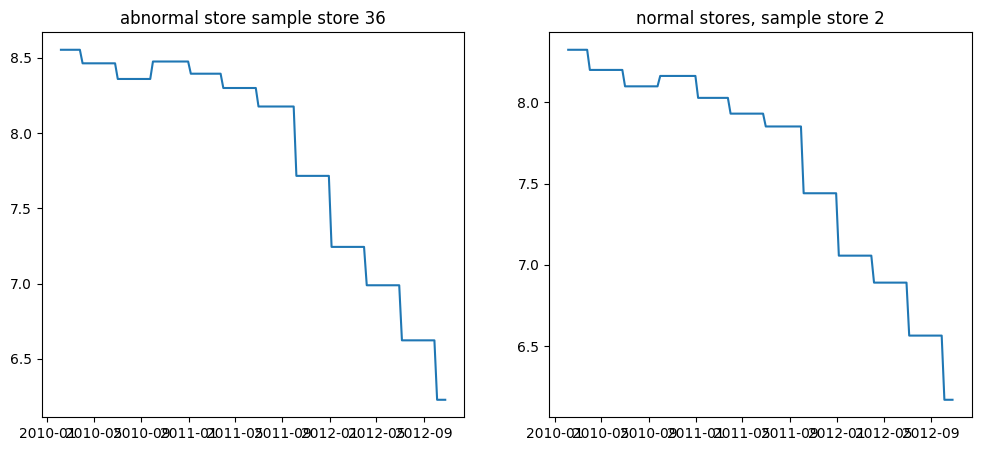

In [45]:
store_abnrm = walmart_copy[walmart_copy["Store"]==36]
store_nrm= walmart_copy[walmart_copy["Store"]==2]
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].plot(store_abnrm["Date"], store_abnrm["Unemployment"])
axes[0].set_title("abnormal store sample store 36")
axes[1].plot(store_nrm["Date"], store_nrm["Unemployment"])
axes[1].set_title("normal stores, sample store 2")

Text(0.5, 1.0, 'normal stores, sample store 2')

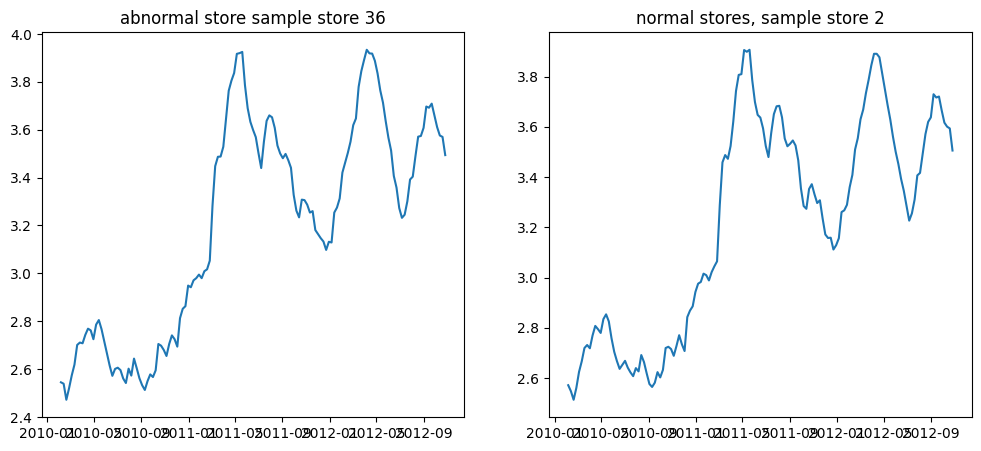

In [46]:
store_abnrm = walmart_copy[walmart_copy["Store"]==36]
store_nrm= walmart_copy[walmart_copy["Store"]==2]
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].plot(store_abnrm["Date"], store_abnrm["Fuel_Price"])
axes[0].set_title("abnormal store sample store 36")
axes[1].plot(store_nrm["Date"], store_nrm["Fuel_Price"])
axes[1].set_title("normal stores, sample store 2")

Text(0.5, 1.0, 'normal stores, sample store 2')

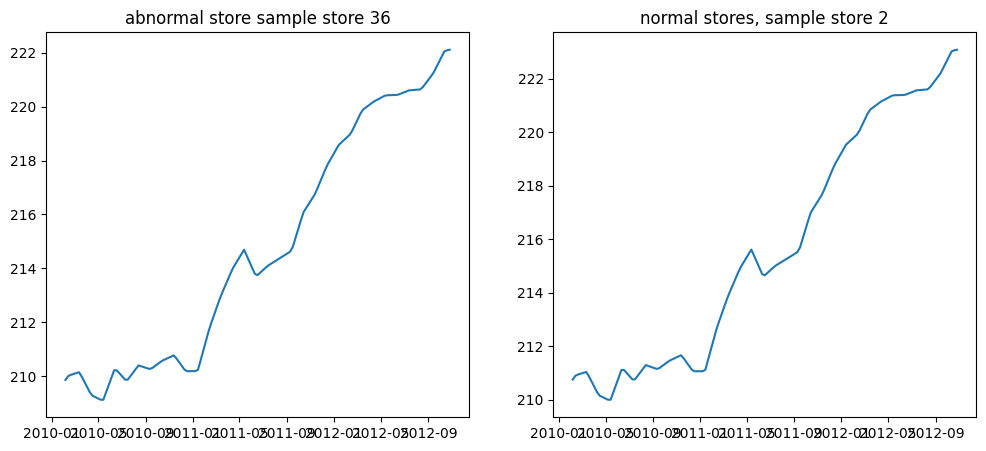

In [47]:
store_abnrm = walmart_copy[walmart_copy["Store"]==36]
store_nrm= walmart_copy[walmart_copy["Store"]==2]
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].plot(store_abnrm["Date"], store_abnrm["CPI"])
axes[0].set_title("abnormal store sample store 36")
axes[1].plot(store_nrm["Date"], store_nrm["CPI"])
axes[1].set_title("normal stores, sample store 2")

Text(0.5, 1.0, 'normal stores, sample store 2')

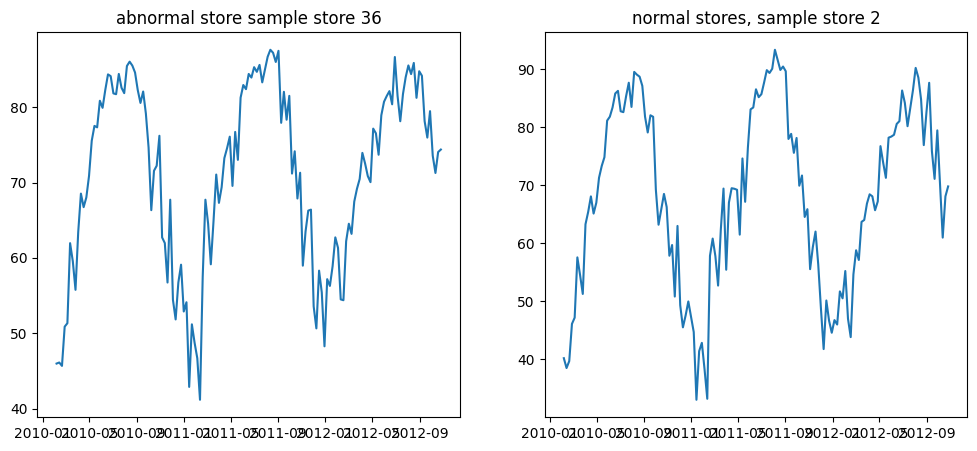

In [48]:
store_abnrm = walmart_copy[walmart_copy["Store"]==36]
store_nrm= walmart_copy[walmart_copy["Store"]==2]
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].plot(store_abnrm["Date"], store_abnrm["Temperature"])
axes[0].set_title("abnormal store sample store 36")
axes[1].plot(store_nrm["Date"], store_nrm["Temperature"])
axes[1].set_title("normal stores, sample store 2")

In [49]:
## preprocessing

In [50]:
walmart_copy.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [51]:
# now, since this data is not a time series and ml models cannot comprehend dates, before dropping the date column i should derive a signal from that info
# in order to do that, since date is weekly, and range include more than 1 year, week number can be a signal for estimating sales
# but there is a cycling issue, since ml algorithms cannot know 1 comes after 52th week, they can be interpreted as too far away from each other
# so ill do sin cos transformation

In [52]:
walmart_copy["Date"].describe()

,Date
count,6435
mean,2011-06-17 00:00:00
min,2010-02-05 00:00:00
25%,2010-10-08 00:00:00
50%,2011-06-17 00:00:00
75%,2012-02-24 00:00:00
max,2012-10-26 00:00:00


In [53]:
model_data=walmart_copy.copy()

In [54]:
week=model_data["Date"].dt.isocalendar().week

In [55]:
week.head()

,week
0,5
1,6
2,7
3,8
4,9


In [56]:
model_data["week_sin"]=np.sin(2*np.pi*week/52)
model_data["week_cos"]=np.cos(2*np.pi*week/52)

In [57]:
model_data.head(55)
# now i can see at the end of the year-week52's sin value and beginning of the year-week1's sin value perfectly close to each other

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,week_sin,week_cos
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,0.568065,0.822984
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,0.663123,0.748511
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,0.748511,0.663123
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,0.822984,0.568065
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,0.885456,0.464723
5,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,0.935016,0.354605
6,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,0.970942,0.239316
7,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,0.992709,0.120537
8,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,1.0,-0.0
9,1,2010-04-09,1545418.53,0,65.86,2.770,210.622857,7.808,0.992709,-0.120537


In [58]:
# now, the store column, lets encode it
# in order to eliminate dummy trap ill keep first store as intercept
model_data=pd.get_dummies(model_data,columns=["Store"],drop_first=True)

In [59]:
model_data.columns

Index(['Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment', 'week_sin', 'week_cos', 'Store_2', 'Store_3',
       'Store_4', 'Store_5', 'Store_6', 'Store_7', 'Store_8', 'Store_9',
       'Store_10', 'Store_11', 'Store_12', 'Store_13', 'Store_14', 'Store_15',
       'Store_16', 'Store_17', 'Store_18', 'Store_19', 'Store_20', 'Store_21',
       'Store_22', 'Store_23', 'Store_24', 'Store_25', 'Store_26', 'Store_27',
       'Store_28', 'Store_29', 'Store_30', 'Store_31', 'Store_32', 'Store_33',
       'Store_34', 'Store_35', 'Store_36', 'Store_37', 'Store_38', 'Store_39',
       'Store_40', 'Store_41', 'Store_42', 'Store_43', 'Store_44', 'Store_45'],
      dtype='object')

In [60]:
pd.set_option("display.max_columns", None)
model_data[model_data.index==142]
model_data[model_data.index==143]

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,week_sin,week_cos,Store_2,Store_3,Store_4,Store_5,Store_6,Store_7,Store_8,Store_9,Store_10,Store_11,Store_12,Store_13,Store_14,Store_15,Store_16,Store_17,Store_18,Store_19,Store_20,Store_21,Store_22,Store_23,Store_24,Store_25,Store_26,Store_27,Store_28,Store_29,Store_30,Store_31,Store_32,Store_33,Store_34,Store_35,Store_36,Store_37,Store_38,Store_39,Store_40,Store_41,Store_42,Store_43,Store_44,Store_45
143,2010-02-05,2136989.46,0,40.19,2.572,210.752605,8.324,0.568065,0.822984,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [61]:
model_data=model_data.drop(columns=["Date"])

In [62]:
# analysis

In [63]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

In [64]:
model_data.columns

Index(['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI',
       'Unemployment', 'week_sin', 'week_cos', 'Store_2', 'Store_3', 'Store_4',
       'Store_5', 'Store_6', 'Store_7', 'Store_8', 'Store_9', 'Store_10',
       'Store_11', 'Store_12', 'Store_13', 'Store_14', 'Store_15', 'Store_16',
       'Store_17', 'Store_18', 'Store_19', 'Store_20', 'Store_21', 'Store_22',
       'Store_23', 'Store_24', 'Store_25', 'Store_26', 'Store_27', 'Store_28',
       'Store_29', 'Store_30', 'Store_31', 'Store_32', 'Store_33', 'Store_34',
       'Store_35', 'Store_36', 'Store_37', 'Store_38', 'Store_39', 'Store_40',
       'Store_41', 'Store_42', 'Store_43', 'Store_44', 'Store_45'],
      dtype='object')

In [65]:
X=model_data.drop(columns=["Weekly_Sales"])
y=model_data["Weekly_Sales"]

In [66]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [67]:
print(x_train.shape)
print(x_test.shape)

(4504, 51)
(1931, 51)


In [68]:
# baseline model

In [69]:
scale=StandardScaler()

In [70]:
x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.transform(x_test)

In [71]:
lr=LinearRegression()

In [72]:
lr.fit(x_train_scaled,y_train)

LinearRegression()

In [73]:
y_pred_base=lr.predict(x_test_scaled)

In [74]:
print("r2 score:",r2_score(y_test,y_pred_base))
print("rmse:",np.sqrt(mean_squared_error(y_test,y_pred_base)))

r2 score: 0.916473200893728
rmse: 163417.38541016658


In [75]:
# model selection

In [76]:
pipe=Pipeline([("scale",StandardScaler()),
               ("model",LinearRegression())])

In [77]:
param_grid=[{"model":[LinearRegression()]},
            {"model":[Ridge()],"model__alpha":np.logspace(-3,3,7)},
            {"model":[Lasso()],"model__alpha":np.logspace(-3,3,7)},
            {"model":[ElasticNet()],"model__alpha":np.logspace(-3,3,7),"model__l1_ratio":np.linspace(0.1,0.9,9)},
            {"model":[SVR()],"model__C":[0.1,1,10,100],"model__gamma":["scale","auto"],"model__kernel":["linear","rbf"]},
            {"model":[RandomForestRegressor(random_state=42)],"model__n_estimators":[100,150,200],"model__max_depth":[10,15,20]},
            {"model":[XGBRegressor(random_state=42)],"model__n_estimators":[100,150,200],"model__max_depth":[3,5,7],"model__learning_rate":[0.01,0.1,0.2]}]

In [78]:
grid=GridSearchCV(pipe,param_grid=param_grid,cv=5,n_jobs=-1,scoring="neg_root_mean_squared_error")

In [79]:
grid.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scale', StandardScaler()),
                                       ('model', LinearRegression())]),
             n_jobs=-1,
             param_grid=[{'model': [LinearRegression()]},
                         {'model': [Ridge()],
                          'model__alpha': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])},
                         {'model': [Lasso()],
                          'model__alpha': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])},
                         {'model':...
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=None, n_jobs=None,
                                                 num_parallel_tree=None, ...)],
                          'model__learning_rate': [0.01, 0.1, 0.2],
                          'model__max_depth': [3, 5, 7],
                          'model__n_estimators': [100, 150, 200]}],
             scoring='neg_root_mean_squared_error')

In [80]:
grid.best_params_

{'model': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...),
 'model__learning_rate': 0.2,
 'model__max_depth': 7,
 'model__n_estimators': 200}

In [81]:
pd.set_option("display.max_colwidth", None)
cv_results=pd.DataFrame(grid.cv_results_)
cv_results[["params", "mean_test_score", "std_test_score"]].sort_values("mean_test_score", ascending=False).head(5)
# grid choose xgboostregressor with learning rate:0.2, max_depth:7 and n_estimators:200 as best estimator
# but in order to retain more consistency, i choose second best model with less std_score; xgboost learning rate:0.2,max_depth:5,n_estimators:200

,params,mean_test_score,std_test_score
129,"{'model': XGBRegressor(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=True, eval_metric=None, feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=None, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=None, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=None, n_jobs=None, num_parallel_tree=None, ...), 'model__learning_rate': 0.2, 'model__max_depth': 7, 'model__n_estimators': 200}",-105373.755851,10608.633049
126,"{'model': XGBRegressor(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=True, eval_metric=None, feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=None, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=None, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=None, n_jobs=None, num_parallel_tree=None, ...), 'model__learning_rate': 0.2, 'model__max_depth': 5, 'model__n_estimators': 200}",-107341.162851,6857.471870
128,"{'model': XGBRegressor(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=True, eval_metric=None, feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=None, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=None, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=None, n_jobs=None, num_parallel_tree=None, ...), 'model__learning_rate': 0.2, 'model__max_depth': 7, 'model__n_estimators': 150}",-107641.371889,10915.069856
125,"{'model': XGBRegressor(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=True, eval_metric=None, feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=None, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=None, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=None, n_jobs=None, num_parallel_tree=None, ...), 'model__learning_rate': 0.2, 'model__max_depth': 5, 'model__n_estimators': 150}",-112209.308924,7108.604043
120,"{'model': XGBRegressor(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=True, eval_metric=None, feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=None, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=None, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=None, n_jobs=None, num_parallel_tree=None, ...), 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200}",-112870.810756,11498.038993


In [82]:
best=XGBRegressor(random_state=42,max_depth=5,n_estimators=200,learning_rate=0.2)

In [83]:
best.fit(x_train_scaled,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [84]:
y_pred_xgbr=best.predict(x_test_scaled)

In [85]:
print("r2 score:",r2_score(y_test,y_pred_xgbr))
print("rmse:",np.sqrt(mean_squared_error(y_test,y_pred_xgbr)))

r2 score: 0.9667421115255664
rmse: 103117.57106578418


In [86]:
# is this worth to try? Friedman test

In [87]:
from scipy.stats import friedmanchisquare

In [88]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results["model_name"] = cv_results["param_model"].apply(lambda x: type(x).__name__)

split_cols = [c for c in cv_results.columns if c.startswith("split") and c.endswith("_test_score")]

best_per_model = cv_results.loc[cv_results.groupby("model_name")["mean_test_score"].idxmax()]

scores_matrix = best_per_model.set_index("model_name")[split_cols]
print(scores_matrix)

stat, p = friedmanchisquare(*[scores_matrix.loc[m] for m in scores_matrix.index])
print("statistics:", stat)
print("p-value:", p)

                       split0_test_score  split1_test_score  \
model_name                                                    
ElasticNet                -151333.555559     -162617.644165   
Lasso                     -151353.297113     -162617.125083   
LinearRegression          -151356.917466     -162593.734310   
RandomForestRegressor     -230010.156869     -229500.290045   
Ridge                     -151349.765155     -162595.008514   
SVR                       -328102.898930     -343161.827893   
XGBRegressor               -96353.611121     -104921.700323   

                       split2_test_score  split3_test_score  split4_test_score  
model_name                                                                      
ElasticNet                -157100.051262     -169926.217822     -157966.083729  
Lasso                     -157097.612831     -169916.593020     -157954.781213  
LinearRegression          -157088.622879     -169951.061501     -157933.182692  
RandomForestRegressor     -

In [89]:
# p_value came out really small:0.0003, so, we can reject h0, models' results are significantly different from each other,
# our trials of searching the best model is not nonsense, model performance differences are not just noise and best model cannot defend only by it has lucky fold

In [90]:
# feature importance

In [91]:
best.feature_importances_

array([0.00032749, 0.00015416, 0.00013904, 0.00065776, 0.00211564,
       0.00096081, 0.00055884, 0.05250895, 0.01560055, 0.08187614,
       0.02593695, 0.03275038, 0.01559853, 0.00085198, 0.01216733,
       0.06227249, 0.01133148, 0.00017698, 0.08788574, 0.08009998,
       0.01483462, 0.02721198, 0.00307698, 0.00231073, 0.0171098 ,
       0.121262  , 0.00328119, 0.00039953, 0.01221689, 0.01244108,
       0.00690162, 0.00078003, 0.05583205, 0.01266555, 0.01746717,
       0.01337076, 0.01202075, 0.00517387, 0.0375971 , 0.        ,
       0.00171628, 0.01702501, 0.01071628, 0.02930827, 0.01469214,
       0.00105713, 0.00712764, 0.01501981, 0.00572002, 0.03269048,
       0.005002  ], dtype=float32)

In [92]:
model_data.shape

(6435, 52)

In [93]:
model_data.columns[26]

'Store_20'

In [94]:
importances = pd.Series(best.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
importances.head(15)
# okay this tells us store 20 is important but this is not very actionable insight, what else is important signal for our sales other than stores?

,0
Store_20,0.121262
Store_13,0.087886
Store_4,0.081876
Store_14,0.080100
Store_10,0.062272
Store_27,0.055832
Store_2,0.052509
Store_33,0.037597
Store_6,0.032750
Store_44,0.032690


In [95]:
importances[~importances.index.str.startswith("Store")]

,0
Unemployment,0.002116
week_sin,0.000961
CPI,0.000658
week_cos,0.000559
Holiday_Flag,0.000327
Temperature,0.000154
Fuel_Price,0.000139


In [96]:
# unemployment is our culprit, it has most effect on our sales
# lets go back on unemployment serie cycles
# since its our most valuable store, lets look at that unemployment on store 20 base

In [97]:
walmart_copy.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [99]:
str_20=walmart_copy[walmart_copy["Store"]==20]

np.float64(-0.09534134450284637)

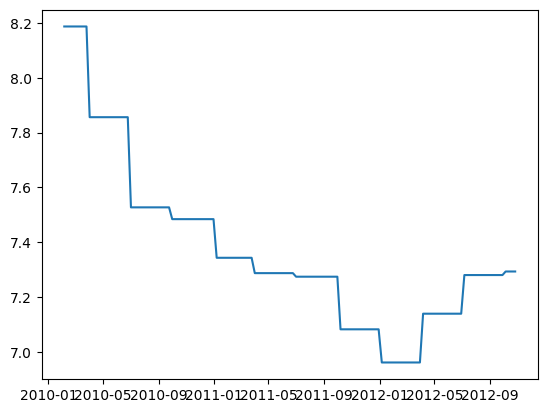

general relationship between weekly sales and unemployment -0.10617608965795429
store_20 relationship between weekly sales and unemployment -0.09534134450284637


In [105]:
plt.plot(str_20["Date"],str_20["Unemployment"])
plt.show()
print("general relationship between weekly sales and unemployment",walmart_copy["Unemployment"].corr(walmart_copy["Weekly_Sales"]))
print("store_20 relationship between weekly sales and unemployment",str_20["Unemployment"].corr(str_20["Weekly_Sales"]))
# as we can see,  there is a trend in unemployment and we are in a rise point right now, so we can expect, unless a shock in economy doesnt occur, a little decrease in our weekly sales since our weekly sales an unemployment has in a little negative relationship

In [ ]:
# thank you